# Map-making

This tutorial will cover how to make coeval boxes with Zeus, relying on the `maps.py` module. 

The available outputs are:
- density field;
- only-brightness temperature (based on the Zeus21_v1 analytical model);
- ionization field (map-level algorithm developed in Zeus21_v2);
- 21-cm signal, including temperature evolution and bubble evolution.

The code produces boxes with the correct correlations and nonlinearities/nonlocalities. 

The notebook relies on the default choice of cosmological and astrophysical parameters; check the other tutorials to produce boxes accounting for different models. 

In [1]:
from zeus21 import maps as m

### 1. Prepare the Zeus21 classes

To compute the T21 brightness temperature in the coeval boxes, the code requires the classes produced by the `T21coefficients.py` and `correlations.py` modules.

See tutorial #1 for details. 

In [2]:
#this cell is basically running all the background we need to have the statistics at all z and k
import zeus21
from matplotlib import pyplot as plt
import numpy as np

# set the User Parameters for the simulation
UserParams = zeus21.User_Parameters()

# set the cosmology parameters for the simulation
CosmoParams = zeus21.Cosmo_Parameters(UserParams=UserParams)

# compute the HMF class
HMFinterp = zeus21.HMF_interpolator(UserParams=UserParams,CosmoParams=CosmoParams)

# set the astro parameters for the simulation
AstroParams = zeus21.Astro_Parameters(CosmoParams=CosmoParams)

# compute the T21 coefficients (cosmic dawn + eor)
T21global = zeus21.get_T21_coefficients(UserParams=UserParams, CosmoParams=CosmoParams, AstroParams=AstroParams, HMFinterp=HMFinterp)

# compute the analytical T21 power spectrum (cosmic dawn -- only T21 evolution, the bubbles will enter on the map level)
RSDMODE = 1 # which RSD mode you want, 0 is no RSDs (real space), 1 is spherical (as simulations usually take), 2 is mu~1 (outside the wedge, most relevant for observations)
PS21 = zeus21.Power_Spectra(UserParams, CosmoParams, AstroParams, T21global, RSD_MODE = RSDMODE)

### 2. Set the properties of the coeval boxes

We set as global parameters the properties that will be shared among boxes. 

In [ ]:
Lbox = 200   # box size (in comoving Mpc)
Ncells = 100 # number of cell per box side; the resolution is Lbox/Ncells
seed = 1234  # default random seed, shared to produce the same clustering properties
z = 7. # redshift at which maps are computed 

### 3. Produce maps of the ionization field 

The class ```ReioMapsConfig``` allows the user to set the properties of the reionization computation.

We list here the parameters a regular user will most likely be interested in. Other parameters, defining the precision and computational cost of the computation, are described in `maps.py`.


In [32]:
# this is the default setup the user should use

Reio = m.ReioMapsConfig(
    input_boxlength = Lbox,             # box size (cMpc)
    ncells = Ncells,                    # number of cells per side
    seed = seed,                        # random seed
    PRINT_TIMER = False,                # print timer to track the computation
    COMPUTE_DENSITY_AT_ALLZ = True,     # compute the density field at each of the input z 
    COMPUTE_MASSWEIGHTED = True,        # compute *ALSO* the volume-weighted or mass-weighted ionization field; the latter is only relevant to estimate tau
    COMPUTE_PARTIAL_IONIZATIONS = True, # compute *ALSO* the partial reionization contribution
    COMPUTE_ZREION = False,             # compute 3d map of the redshift at which each cell is first ionized
)

We now generate maps of the ionization field, together with the average ionization fraction $\bar{x}_{\rm HII}$. 

By default, the function ```reionization_maps``` computes the volume-weighted ionization field as a binary map (1 = ionized, 0 = neutral); the redshift at which a cell gets ionized depends on the underlying density field.

If the relative flags are set to True, the user can also compute:
- the mass-weighted reionization field 
- the ionization field including partial-reionization contributions (bubbles below the cell size are accounted for as fractions)

We compare the output maps in the following cell. 
We also compare the map-averaged quantities with $\bar{x}_{\rm HII}$ estimated from the theory (see tutorial #1). 

In [33]:
reio_map = m.reionization_maps(
    CosmoParams = CosmoParams, 
    CoeffStructure = T21global, 
    input_z = T21global.zintegral, # !!! here you can pass a float or an array
    input_boxlength = Lbox,
    ncells = Ncells,
    seed = seed, 
    COMPUTE_DENSITY_AT_ALLZ = Reio.COMPUTE_DENSITY_AT_ALLZ,
    COMPUTE_MASSWEIGHTED = Reio.COMPUTE_MASSWEIGHTED,
    COMPUTE_PARTIAL_IONIZATIONS = Reio.COMPUTE_PARTIAL_IONIZATIONS,
    COMPUTE_ZREION = Reio.COMPUTE_ZREION
)

Generating density field...
    done in 0min 0s
Smoothing density field...
    done in 0min 6s
Evolving density field...
    done in 0min 1s
Generating ionized field...


100%|██████████| 99/99 [00:06<00:00, 15.07it/s]


    done in 0min 6s
Computing mass-weighted field...
Computing mass-weighted ionized fraction...
    done in 0min 1s
Computing partially ionized field...


100%|██████████| 99/99 [00:04<00:00, 24.45it/s]


Computing partial ionized fraction...
    done in 0min 4s
Computing mass-weighted partially ionized field...


100%|██████████| 99/99 [00:01<00:00, 61.83it/s]


Computing mass-weighted partial ionized fraction...


100%|██████████| 99/99 [00:00<00:00, 1033.49it/s]


    done in 0min 1s
Total computation time: 0min 22s


Text(0.5, 0.98, 'Ionization field, $z=7$ ($x_{\\rm HII}=1=$ ionized)')

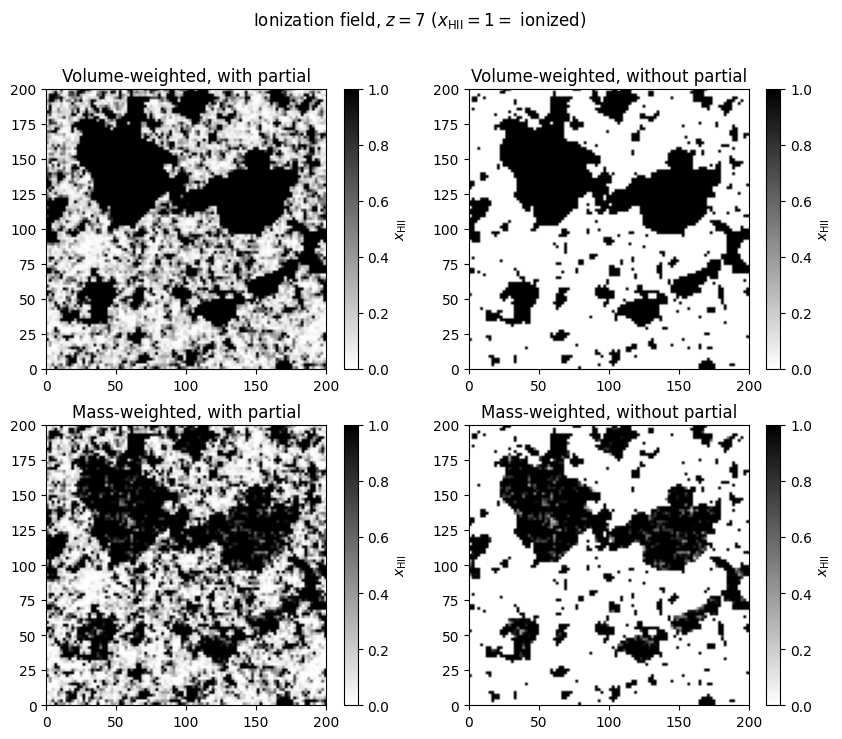

In [34]:
# plot the boxes

z_id =  zeus21.z21_utilities.find_nearest_idx(reio_map.input_z, z)[0] # index of z in the input_z array passed to reionization_maps 
slice_id = 0 # which slice of the (Ncells, Ncells, Ncells) coeval box should be plotted

fig, ax = plt.subplots(2,2,figsize=(10,8))

im = ax[0,0].imshow(reio_map.ion_field_partial_allz[z_id][slice_id], vmin = 0, vmax = 1, cmap = 'binary', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$x_{\rm HII}$')
ax[0,0].set_title(r'Volume-weighted, with partial')

im = ax[0,1].imshow(reio_map.ion_field_allz[z_id][slice_id], vmin = 0, vmax = 1, cmap = 'binary', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$x_{\rm HII}$')
ax[0,1].set_title(r'Volume-weighted, without partial')

im = ax[1,0].imshow(reio_map.ion_field_partial_massweighted_allz[z_id][slice_id], vmin = 0, vmax = 1, cmap = 'binary', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$x_{\rm HII}$')
ax[1,0].set_title(r'Mass-weighted, with partial')

im = ax[1,1].imshow(reio_map.ion_field_massweighted_allz[z_id][slice_id], vmin = 0, vmax = 1, cmap = 'binary', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$x_{\rm HII}$')
ax[1,1].set_title(r'Mass-weighted, without partial')

plt.suptitle(r'Ionization field, $z=%g$'%z + r' ($x_{\rm HII}=1=$ ionized)')

Text(0, 0.5, '$\\bar{x}_{\\rm HII}$')

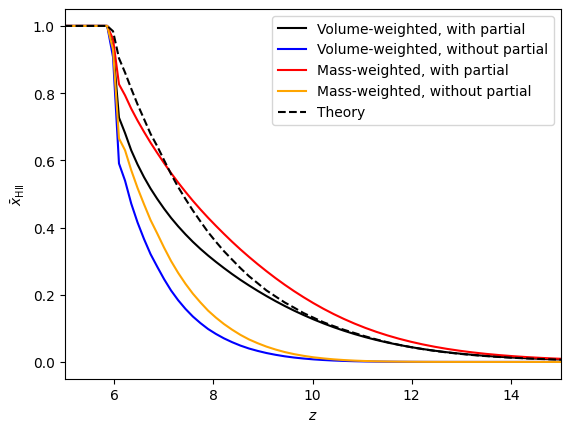

In [35]:
# plot the average

plt.plot(T21global.zintegral, reio_map.ion_frac_partial, label = r'Volume-weighted, with partial', color='k')
plt.plot(T21global.zintegral, reio_map.ion_frac, label = r'Volume-weighted, without partial', color='b')
plt.plot(T21global.zintegral, reio_map.ion_frac_partial_massweighted, label = r'Mass-weighted, with partial', color='r')
plt.plot(T21global.zintegral, reio_map.ion_frac_massweighted , label = r'Mass-weighted, without partial', color='orange')

plt.plot(T21global.zintegral, 1. - T21global.xHI_avg, label = 'Theory', color='k', ls='--')

plt.xlim(5,15)
plt.legend(loc=1)
plt.xlabel(r'$z$')
plt.ylabel(r'$\bar{x}_{\rm HII}$')

When comparing $\bar{x}_{\rm HII}$ from the boxes with the theoretical expectation, keep in mind few things:
- the theoretical value is expected to match ???
- you may notice a step-like feature at the end of the EoR: this is caused by the fact that bubbles suddenly become larger than the box; the feature can be removed by using larger boxes

### 4. Produce maps of the T21 signal 

The class ```T21_maps``` allows the user to compute maps tracking the evolution of the brightness temperature. If the ionization field is passed as input, the map also contain bubbles.

To produce the boxes, the code first initializes a lognormal density field. The clustering properties of the temperature field are then set by rescaling this field via the theoretical power spectrum, accounting for both linear and non-linear contributions.


In [64]:
T21_map = m.T21_maps(
    CosmoParams = CosmoParams, 
    CoeffStructure = T21global, 
    PowerSpectra = PS21, 
    input_z = [z], # !!! in this case you can pass only 1d lists or arrays
    ReioMaps_config = Reio,  
    USE_xHII_MAPS = True, # if False, does not compute the bubble contribution
    COMPUTE_TAU = True, # compute the CMB optical depth - makes the computation heavier
    input_boxlength = Lbox, 
    ncells = Ncells, 
    seed = seed,
    smooth_box = True, # allows the user to smooth the box with Gaussian kernel
    input_Resolution = 4. # size of the Gaussian kernel (in cMpc)
)

In [65]:
# each redshift requires its own call

T21_map_highz = m.T21_maps(
    CosmoParams = CosmoParams, 
    CoeffStructure = T21global, 
    PowerSpectra = PS21, 
    input_z = [z+5], # !!! in this case you can pass only 1d lists or arrays
    ReioMaps_config = Reio,  
    USE_xHII_MAPS = True, # if False, does not compute the bubble contribution
    COMPUTE_TAU = True, # compute the CMB optical depth - makes the computation heavier
    input_boxlength = Lbox, 
    ncells = Ncells, 
    seed = seed,
)

Text(0.5, 0.98, 'Boxes at $z=12$')

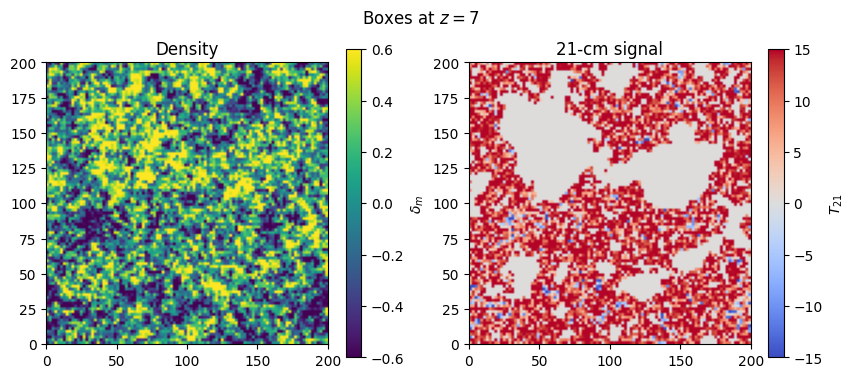

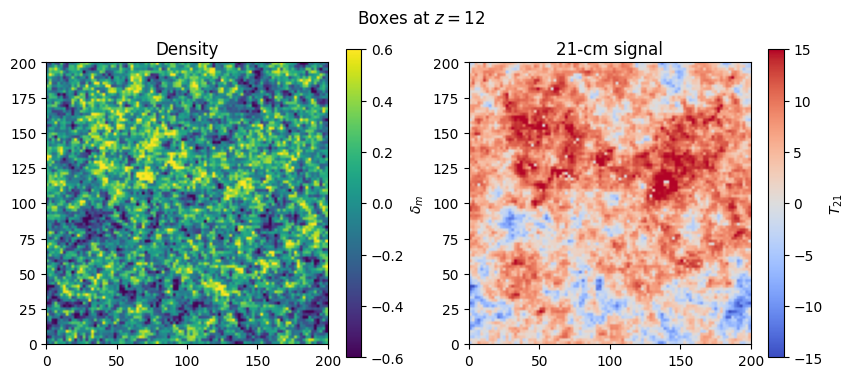

In [66]:
# plot the boxes

z_id = 0 # index of z in the input_z array passed to reionization_maps 
slice_id = 0 # which slice of the (Ncells, Ncells, Ncells) coeval box should be plotted

fig, ax = plt.subplots(1,2,figsize=(10,4))

im = ax[0].imshow(T21_map.density[z_id][slice_id], vmin = -0.6, vmax = 0.6, cmap = 'viridis', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$\delta_m$')
ax[0].set_title(r'Density')

im = ax[1].imshow(T21_map.T21[z_id][slice_id], vmin = -15, vmax = 15, cmap = 'coolwarm', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$T_{21}$')
ax[1].set_title(r'21-cm signal')

plt.suptitle(r'Boxes at $z=%g$'%z)

fig, ax = plt.subplots(1,2,figsize=(10,4))

im = ax[0].imshow(T21_map_highz.density[z_id][slice_id], vmin = -0.6, vmax = 0.6, cmap = 'viridis', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$\delta_m$')
ax[0].set_title(r'Density')

im = ax[1].imshow(T21_map_highz.T21[z_id][slice_id], vmin = -15, vmax = 15, cmap = 'coolwarm', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$T_{21}$')
ax[1].set_title(r'21-cm signal')

plt.suptitle(r'Boxes at $z=%g$'%(z+5))


The function also allows the user to smooth the density field with a Gaussian kernel of given resolution.

Text(0.5, 0.98, 'Boxes at $z=7$ smoothed over $R=4$ Mpc')

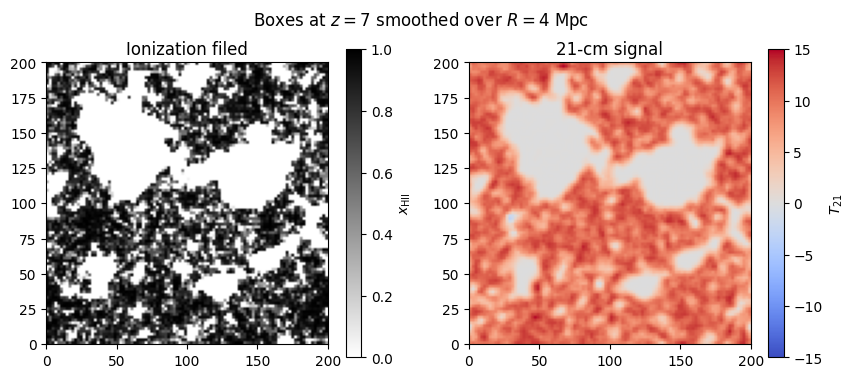

In [67]:
# plot the smoothed boxes

z_id = 0 # index of z in the input_z array passed to reionization_maps 
slice_id = 0 # which slice of the (Ncells, Ncells, Ncells) coeval box should be plotted

fig, ax = plt.subplots(1,2,figsize=(10,4))

im = ax[0].imshow(T21_map.xHI_smooth[z_id][slice_id], vmin = 0, vmax = 1, cmap = 'binary', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$x_{\rm HII}$')
ax[0].set_title(r'Ionization filed')

im = ax[1].imshow(T21_map.T21_smooth[slice_id], vmin = -15, vmax = 15, cmap = 'coolwarm', extent=(0,Lbox,0,Lbox))
plt.colorbar(im, label = r'$T_{21}$')
ax[1].set_title(r'21-cm signal')

plt.suptitle(r'Boxes at $z=%g$'%z + r' smoothed over $R=%g$ Mpc'%T21_map.input_Resolution)

Finally, we can compare the CMB optical depth estimated from the theoretical reionization history with the one obtained based on the evolution in the boxes.

In [63]:
print('CMB optical depth from the theory: ' + str(round(T21global.tau_reio_val,3)))
print('CMB optical depth from the boxes: ' + str(round(T21_map.tau,3)))

CMB optical depth from the theory: 0.057
CMB optical depth from the boxes: 0.059
